# Monitor water and vegetation in an oasis with ArcGIS Notebooks


In this notebook, you'll use ArcGIS API for Python to identify water and vegetation in the El Fayoum oasis in Egypt. You'll select a recent satellite image and apply the NDVI and NDWI spectral indices to it. You'll then identify and delineate the water and vegetation pixels by applying thresholding and masking. You will also learn to apply a stretch to a raster to symbolize it with a specific color, and generate histograms for spectral index rasters. 

**Note:** This is the third notebook in the [Analyze imagery with ArcGIS Notebooks](https://learn.arcgis.com/en/paths/analyze-imagery-with-arcgis-notebooks/) learning path. For an optimal experience, consider doing all four notebooks in the order proposed.

This notebook was last tested on August 19, 2025.

## Table of contents

* [Introduction](#introduction)
* [Set up the environment](#environment)
* [Get the data](#data)
* [Visualize and explore the imagery](#visualize)
* [Perform the analysis](#analysis)
* [Generate spectral index histograms](#histograms)
* [Stretch goal](#stretch)
* [Summary](#summary)
* [Acknowledgments](#acknowledgments)

## Introduction <a class="anchor" id="introduction"></a>

[El Fayoum](https://en.wikipedia.org/wiki/Faiyum) (or Faiyum or Fayum) is a large oasis in the Egyptian part of the Sahara desert. It has existed since ancient Egyptian times and receives its water from the Nile river by way of a canal system. The water arriving through the canals can vary in quantity, with direct consequences on the oasis' water bodies and agriculture production. As a GIS analyst for the local agriculture board, you want to identify and delineate water bodies and vegetation in the oasis to monitor and better manage these valuable resources. 

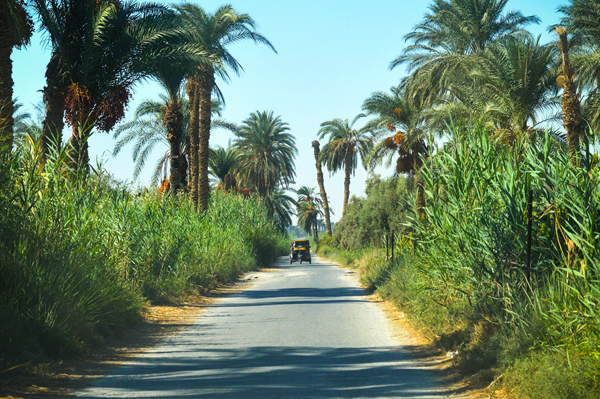


## Set up the environment <a class="anchor" id="environment"></a>

First, you need to import the Python modules and functions that you'll use in this notebook and that are not part of Python's default installation. Importing objects and functions makes them available for your code.   

1. Run the cell below to import the required objects and functions.

In [1]:
# Import GIS from the arcgis package - this will allow you to create a GIS object to connect to ArcGIS Online.
from arcgis import GIS

# Import the ImageryLayer class from the arcgis.raster module so you can create imagery layer objects.
from arcgis.raster import ImageryLayer

# Import the apply, clip, ndvi, ndwi, mask, stretch, colormap functions from arcgis.raster.functions 
# so you can use them to manipulate the imagery layers.
from arcgis.raster.functions import apply, clip, ndvi, ndwi, mask, stretch, colormap

# Import the Polygon class so you can create an area of interest (AOI) polygon.
from arcgis.geometry import Polygon

# Import the intersects and within functions from arcgis.geometry.filters so you can find images relevant to the AOI.
from arcgis.geometry.filters import intersects, within

# Import the datetime module so you can create datetime objects to filter imagery by date.
import datetime as dt

# Import the HBox widget from ipywidgets so you can display maps side by side in your Jupyter notebook results.
from ipywidgets import HBox, Layout

**Tip:** If your notebook remains idle too long at any point in this workflow, it might time out. If that happens or any step takes longer than a couple of minutes to run, you should restart the kernel: on the Notebook's ribbon, click **Kernel** and **Restart**. Then run the cells again from the beginning of the notebook.

Next, you'll create an anonymous connection to ArcGIS Online.  

2. Run the cell below to create the connection.

In [2]:
# Create a variable called "gis" that is a GIS object.
# In this case, since no organization or login credentials are supplied, 
# it will be an anonymous connection to ArcGIS Online.
gis = GIS()

## Get the data <a class="anchor" id="data"></a>

### Create an imagery layer instance

You will use Landsat satellite imagery. You'll create an **ImageryLayer** instance from the [Multispectral Landsat image service](https://www.arcgis.com/home/item.html?id=d9b466d6a9e647ce8d1dd5fe12eb434b), hosted in [ArcGIS Living Atlas of the World](https://livingatlas.arcgis.com/en/home/).

3. Run the cell below to create the imagery layer instance.

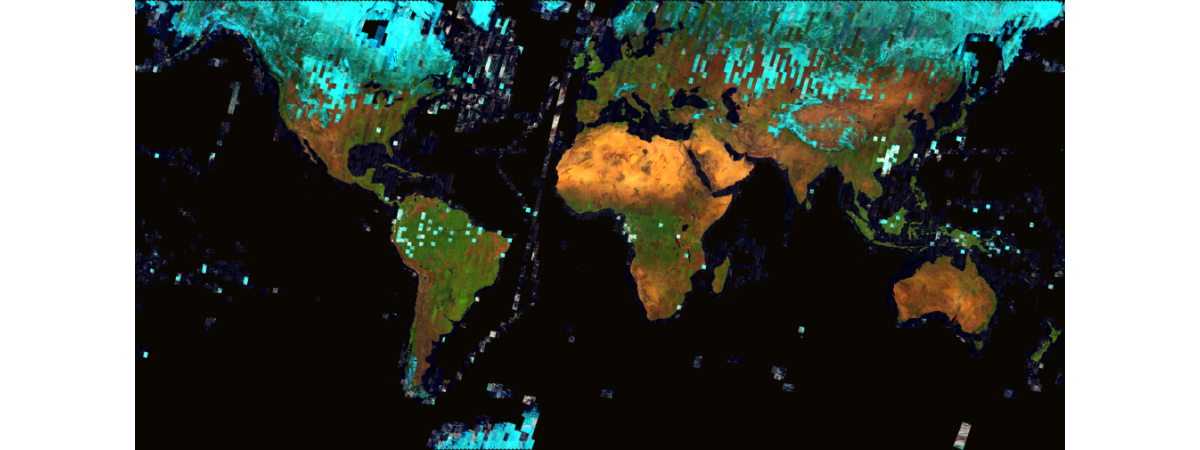

In [3]:
# Create a variable called landsat_imagery that is an ImageryLayer object, 
# getting its images from the online Multispectral Landsat image service.
landsat_imagery = ImageryLayer("https://landsat2.arcgis.com/arcgis/rest/services/Landsat/MS/ImageServer")

# Draw the imagery layer.
landsat_imagery

### Define your area of interest

Next, you'll define your area of interest (AOI) as a [polygon](https://developers.arcgis.com/python/guide/part2-working-with-geometries/#Creating-Polygon-objects) focused on the oasis of El Fayoum in Egypt. This will be a rectangular polygon, defined by latitude and longitude coordinates in the [WGS84 coordinate system](https://developers.arcgis.com/documentation/spatial-references/#4326---gps).

4. Run the cell below to create a polygon object from a list of coordinates.

In [4]:
# Create a polygon object from a list of five coordinates,representing the polygon's corners.
# The last one is at the same location as the first to close the polygon.
fayoum_aoi = Polygon({"rings": [[[30.280513520851272,29.598338111312678],
                                 [30.280513520851272,28.97763846954842],
                                 [31.358450967788027,28.97763846954842],
                                 [31.358450967788027,29.598338111312678],
                                 [30.280513520851272,29.598338111312678]]],
                        "spatialReference": {"wkid": 4326}})
# The spatial reference of the polygon is set using the well-known ID or "wkid" code of 4326, which codes for WGS84.  

5. Run the cell below to view the polygon in a map.

In [5]:
# Create a variable called map that is an instance of the gis.map class.
map1 = gis.map()

# Draw the fayoum_aoi polygon object on the map.
map1.content.draw(shape=fayoum_aoi)

# Set the extent of the map to the envelope of the feature.
map1.extent = dict(fayoum_aoi.envelope)

# Draw the map.
map1

Map(extent={'xmin': 30.280513520851272, 'ymin': 28.97763846954842, 'xmax': 31.358450967788027, 'ymax': 29.5983…

The AOI includes the El Fayoum oasis and some of the surrounding desert. On the southeast side, you can see a portion of the Nile valley. 

### Select a specific Landsat scene

You'll select a recent Landsat scene captured between February and March 2022. This is a period of the year in which most of the vegetation in the El Fayoum oasis is quite green and lush, which should make it easier to distinguish vegetated areas from other land-cover types. 

Using the **filter_by** function, you first find all the scenes in the Landsat service that contain the AOI and are within the desired time range. Then, using the **query** function, you'll order scenes selected by cloud cover and keep only the first one (that is, the one with the least cloud cover). You'll display that record.  

6. Run the cell below to filter the Landsat scenes.

In [6]:
# Create a variable called selected that contains scenes that occur 
# in the desired time range and are within the AOI.
selected = landsat_imagery.filter_by(time=[dt.datetime(2022, 2, 1), dt.datetime(2022, 3, 31)],
                               geometry=within(fayoum_aoi))

# Create a query to choose the one scene with the least amount of cloud cover.
query_result = selected.query(out_fields="AcquisitionDate, GroupName, CloudCover, DayOfYear", 
                    order_by_fields="CloudCover",
                    result_record_count=1)


# Display the query result.
query_result

<FeatureSet> 0 features

The result is **0 features**, which means that there are no scenes selected. 

This is because the El Fayoum oasis is not contained entirely within a single satellite scene. Instead of **within**, you'll use **intersects** to find the images that intersect partially with the desired extent. You'll query for the five scenes with the least cloud cover and will review them manually to find the most suitable scene.   

7. Run the cell below to filter the Landsat scenes.

In [7]:
# Find scenes that intersect the AOI, rather than scenes that fall within it.
selected = landsat_imagery.filter_by(time=[dt.datetime(2022, 2, 1), dt.datetime(2022, 3, 31)],
                               geometry=intersects(fayoum_aoi))

# Create a query to get the top five records with the least amount of cloud cover.
query_result = selected.query(out_fields="AcquisitionDate, GroupName, CloudCover, DayOfYear", 
                    order_by_fields="CloudCover",
                    result_record_count=5)

# Convert the result into a data frame, which is a convenient format to access and manipulate this data.  
df = query_result.sdf

# Display the data frame.
df

,OBJECTID,AcquisitionDate,GroupName,CloudCover,DayOfYear,SHAPE
0,3512019,2022-03-05 08:23:52,LC08_L1TP_176039_20220305_20220314_02_T1_MTL,0.0016,39,"{""rings"": [[[3681029.6744999997, 3627718.24149..."
1,3543159,2022-03-28 08:30:12,LC08_L1TP_177040_20220328_20220405_02_T1_MTL,0.0024,40,"{""rings"": [[[3466439.2870000005, 3442928.78999..."
2,3454299,2022-02-08 08:30:34,LC08_L1TP_177040_20220208_20220212_02_T1_MTL,0.0025,40,"{""rings"": [[[3446380.7386999987, 3354224.96660..."
3,3543158,2022-03-28 08:29:48,LC08_L1TP_177039_20220328_20220405_02_T1_MTL,0.0052,39,"{""rings"": [[[3509787.9351999983, 3627733.88279..."
4,4361954,2022-02-16 08:30:38,LC09_L1TP_177040_20220216_20230427_02_T1_MTL,0.0054,40,"{""rings"": [[[3466356.3718000017, 3442576.55290..."


Observe the five records' attributes: for all of them, the acquisition date (**AcquisitionDate**) is within the range you wanted, and the amount of cloud cover (**CloudCover**, in percentages) is very low, as desired.

You'll put the scene of the first record in a variable, referring to it by its OBJECTID attribute. Then you'll display it in a map along the El Fayoum AOI for visual inspection.   

8. Run the cell below to show the first scene on the map.

In [8]:
# Make a variable containing the first scene, referenced by OBJECTID. Get the first scene.
# Python lists can be accessed by index number, and index values start at 0, so [0] is the first item.
selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[0]['OBJECTID']}")

# Get the other scenes down the list (not currently used, will be used later).
#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[1]['OBJECTID']}")
#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[2]['OBJECTID']}")
#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[3]['OBJECTID']}")
#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[4]['OBJECTID']}")

# Make a map.
map2 = gis.map()

# Add the layer to the map.
map2.content.add(selected_scene)
                                           
# Add the AOI polygon to the map.                                       
map2.content.draw(shape=fayoum_aoi)

# Set the extent of the map to the envelope of the AOI.
map2.extent = dict(fayoum_aoi.envelope)
                                           
# Draw the map.
map2

Map(extent={'xmin': 30.280513520851272, 'ymin': 28.97763846954842, 'xmax': 31.358450967788027, 'ymax': 29.5983…

The edge of this first image overlaps only slightly with the AOI, so it is not suitable. You'll now switch the first image with the second one on the list. To do that, in the previous cell, you'll comment a line of code and uncomment another line of code.

9. In the previous cell, add a comment sign (**#**) on the line starting with `selected_scene`.  
Once updated, the line should look like this:  
`#selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[0]['OBJECTID']}")`

10. In the previous cell, remove the comment sign (**#**) on the line right after `# Get the other scenes`.  
Once updated, the line should look like this:  
`selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[1]['OBJECTID']}")`

**Note:**
When you run a code cell, the lines that are commented out (with a **#** sign) are ignored. 

What this does is change the filter expression for the selected_scene variable from `df.iloc[0]` to `df.iloc[1]` to retrieve the second image.

11. Run the previous cell again.

12. Zoom out to see the entire image and the AOI polygon.  

This time, the overlap is much better. The oasis itself appears as a heart-shaped, mostly green area and is well covered by the image. You'll keep this image and use it for the rest of the analysis. 

By default, the Multispectral Landsat image service you are using in this notebook is rendered with the agriculture band combination, composed of the shortwave infrared I, near infrared, and blue bands. It displays vegetation in vivid green, water in bluish black, and desert areas in beige tones. This band combination is great to highlight vegetation, and it is often used for agriculture applications, as its name indicates. However, it also highlights built-up urban environments, bare earth areas, and water, making it useful for many nonagricultural purposes.

13. Optionally, keep displaying more images from the list, by uncommenting other lines under `# Get the other scenes` to see how much they overlap with the OAI.

**Note:**
It can be useful, when writing Python code, to make copies of a line of code that you want to experiment on, and use the commenting out method to change which line runs.

After this search to find a suitable image, you'll choose the second image (`df.iloc[1]`), and you'll put it in the **selected_scene** variable to use in the rest of the notebook.

In [9]:
# Select the second image (df.iloc[1]) and put it in the selected_scene variable: 
selected_scene = landsat_imagery.filter_by(f"OBJECTID={df.iloc[1]['OBJECTID']}")

You have now acquired all the data you need. Next, you'll explore the imagery. 

## Visualize and explore the imagery  <a class="anchor" id="visualize"></a>

You'll now prepare the image and explore it.

The image is much larger than the AOI. You'll clip it to the shape of the AOI, to keep only the part of interest to you. 

14. Run the cell below to clip the image to the AOI.

In [10]:
# Create a variable, fayoum_clipped, to hold the result of clipping the selected scene using the AOI polygon.
fayoum_clipped = clip(selected_scene,
                  geometry=fayoum_aoi)

Next, you'll display the clipped image with the same **Agriculture with DRA** rendering as earlier. 

**Note:** While displaying imagery directly from the **landsat_imagery** layer, the agriculture rendering was the default. However, with derived layers, such as **fayoum_clipped**, you now need to apply the rendering explicitly.  

15. Run the cell below to display the image.

In [11]:
# Create the map.
map3 = gis.map()

# Add the layer and apply the 'Agriculture with DRA' raster function.
map3.content.add(apply(fayoum_clipped, 'Agriculture with DRA'))

# Set the extent of the map to the AOI.
map3.extent = dict(fayoum_aoi.envelope)

# Draw the map.
map3

Map(extent={'xmin': 30.280513520851272, 'ymin': 28.97763846954842, 'xmax': 31.358450967788027, 'ymax': 29.5983…

16. In the map, zoom in and pan to explore the oasis.  

Can you identify the different types of land cover in and around the oasis?

**Hint:** As mentioned earlier, with this rendering, the vegetation appears in bright green, the water in bluish black, and the desert in beige. The built-up areas (towns, villages, and the roads connecting them) appear in brown, or in purple when more zoomed in. 


If you would like to see all the predefined renderings available for the Multispectral Landsat image service besides **Agriculture with DRA**, you can use  **_get_service_info()**.

17. Run the cell below to display the image layer's rendering information.

In [12]:
# Display the image service information narrowing down to the rasterFunctionInfos element, which contains all the predefined renderings.
landsat_imagery._get_service_info()["rasterFunctionInfos"]

[{'name': 'Agriculture with DRA',
  'description': 'Bands shortwave IR-1, near-IR, blue (6, 5, 2) with dynamic range adjustment applied on apparent reflectance. Vigorous veg. is bright green, stressed veg. dull green and bare areas as brown.',
  'help': ''},
 {'name': 'Bathymetric with DRA',
  'description': 'Bands red, green, coastal/aerosol (4, 3, 1) with dynamic range adjustment applied on apparent reflectance. Useful in bathymetric mapping applications.',
  'help': ''},
 {'name': 'Color Infrared with DRA',
  'description': 'Bands near-IR, red, green (5, 4, 3) with dynamic range adjustment applied on apparent reflectance. Healthy vegetation is bright red while stressed vegetation is dull red.',
  'help': ''},
 {'name': 'Geology with DRA',
  'description': 'The band combination (7,6,2) enables easier visualization and extraction of delineation of major structural features like thrust faults and folds, textural characteristics of igneous and sedimentary rocks, and for lithological and

Each predefined rendering available is listed, including its name, the list of the spectral bands involved, and a short description of its use.

**Note:** Any of these renderings can be used when displaying a map like **map3** by replacing **Agriculture with DRA** with the name of the desired rendering.

## Perform the analysis  <a class="anchor" id="analysis"></a>

### Apply vegetation and water indices

In the previous section, you visualized land covers such as vegetation and water at a glance. You now want to identify these land covers more formally and extract the water and vegetation pixels to store them into new [raster](https://pro.arcgis.com/en/pro-app/latest/help/data/imagery/introduction-to-raster-data.htm) layers. 

To do that, you'll apply two spectral indices to the image. 

**Note:** A spectral index uses a mathematical calculation to compute a ratio between different bands for every pixel in an image. The result is a new raster that highlights a specific phenomenon.

The first index you'll apply is the normalized difference vegetation index (NDVI), used to detect vegetation. The second one is the normalized difference water index (NDWI), used to detect water.  

NDVI relies on the near infrared and red bands (or bands 5 and 4) and uses the following formula:

`(NIR - Red) / (NIR + Red)`

NDWI relies on the green and near infrared bands (or bands 3 and 5) and uses the following formula:

`(Green - NIR) / (Green + NIR)`


18. Run the cell below to apply NDVI and NDWI to the image and derive new rasters.

In [13]:
# Create a variable to hold the NDVI raster derived from the image. 
# The raster will highlight vegetation.
fayoum_ndvi = ndvi(fayoum_clipped,
                    band_indexes="5 4")

# Create a variable to hold the NDWI raster derived from the image.
# The raster will highlight water. 
fayoum_ndwi = ndwi(fayoum_clipped,
                    band_indexes="5 3")

You will display the two resulting rasters in side-by-side maps. To do that, you'll define a function: **side_by_side**.  

19. Run the cell below to define the **side_by_side** function.

In [14]:
# Define the side_by_side function to display two maps together in the Jupyter notebook results.
def side_by_side(raster_1, raster_2, map_extent):
    """ Method for displaying 2 rasters side by side (on the same map extent) """
    # Create the maps.
    map_1 = gis.map()
    map_2 = gis.map()
    
    # Add the input rasters to the maps.
    map_1.content.add(raster_1)
    map_2.content.add(raster_2)
    
    # Set the extents to be the same using the specified input extent.
    map_1.extent = map_2.extent = map_extent
    
    # Synchronize navigation of the maps.
    map_1.sync_navigation(map_2)

    # Define a layout for each map.
    map_1.layout=Layout(flex='1 1', padding='6px',  width='50%')
    map_2.layout=Layout(flex='1 1', padding='6px',  width='50%')
    
    # Make a horizontal box layout widget to show the two maps.
    box = HBox([map_1, map_2])
    
    # Return the widget to show the maps.
    return box

20. Run the cell below to call the **side_by_side** function on the two rasters, with the extent of the AOI envelope.

In [15]:
# Call the side_by_side function and set its parameters to the two spectral index rasters 
# and the extent.
side_by_side(raster_1=fayoum_ndvi,
          raster_2=fayoum_ndwi,
          map_extent=dict(fayoum_aoi.envelope))

In the NDVI raster, the highest values (in white or near white) denote areas covered with healthy vegetation. The areas with the lowest values (in black) represent water. The areas with medium values (in medium gray) represent desert or built-up areas.

In the NDWI raster, the highest values (in white) represent water. The areas with the lowest values (in black) represent vegetation. The areas with medium values (in medium gray) represent desert or built-up areas.

### Extract the vegetation and water pixels

From the NDVI raster, you want to clearly distinguish the pixels that represent vegetation from those that do not. You know that the vegetation pixels have the highest values, so you will look for the pixels that have a value equal or greater to a specific threshold. Knowing that NDVI values can vary from -1 to +1, you'll consider NDVI values greater than 0.3 as representing vegetation. 

**Note:**
There are different approaches to finding the appropriate threshold value for a particular application and dataset. One of them is trial and error. You will also learn about another method later in this notebook, when exploring index histograms. 

You will create a binary raster that holds only two possible values: 1 if the NDVI pixel value was below the threshold, 0 if it was above. You can think of this new raster as answering the question "is this vegetation?" and showing True/False values, where 1 is true and 0 is false.

21. Run the cell below to create a binary vegetation raster. 

In [16]:
# Create a variable holding a binary raster, where vegetation pixels have a value of 
# and other pixels have a value of 0, based on a 0.3 threshold.
fayoum_ndvi_binary = fayoum_ndvi > 0.3

Similarly, in the NDWI raster, you want to clearly distinguish the pixels that represent water from those that do not. NDWI values can also vary from -1 to +1. You'll consider NDWI values greater than 0 as representing water.

22. Run the cell below to create a binary water raster. 

In [17]:
# Create a variable holding a binary raster, where water pixels have a value of 1 
# and other pixels have a value of 0, based on a 0 threshold.
fayoum_ndwi_binary = fayoum_ndwi > 0

You'll display the two binary rasters side by side. You'll apply a [stretch](https://developers.arcgis.com/python/api-reference/arcgis.raster.functions.html#stretch) to ensure that the rasters display with the 0 and 1 values as black and white. 

23. Run the cell below to display the two binary rasters.

In [18]:
# Call the side_by_side function to display the two rasters in side-by-side maps.
# For each input raster, apply the MinMax stretch and enable DRA.
side_by_side(raster_1=stretch(fayoum_ndvi_binary, stretch_type='MinMax', dra=True),
          raster_2=stretch(fayoum_ndwi_binary, stretch_type='MinMax', dra=True),
          map_extent=dict(fayoum_aoi.envelope))

Next, you'll use the **mask** function to keep only the pixels with a value of 1 for each binary raster. The other pixels will be turned to **Null** values. The resulting rasters will only contain the extracted vegetation and water pixels.  

24. Run the cell below to extract the 1 values of the two binary rasters.

In [19]:
# Create a variable to hold a raster of vegetation pixels using the mask function.
vegetation_pixels = mask(raster=fayoum_ndvi_binary,
                    included_ranges=[1,1])

# Create a variable to hold a raster of water pixels using the mask function.
water_pixels = mask(raster=fayoum_ndwi_binary,
                    included_ranges=[1,1])


You'll display the resulting vegetation and water rasters side by side.  

25. Run the cell below to display the two rasters.

In [20]:
side_by_side(raster_1=vegetation_pixels,
          raster_2=water_pixels,
          map_extent=dict(fayoum_aoi.envelope))

**Note:** Remember that the value of the pixels in both masked rasters can only be 1 or Null. By default, the 1 values are displayed in black. 

In the masked vegetation raster, you can see that much of the oasis is covered in vegetation, with the exception of towns, villages, and water bodies. The vegetation in the El Fayoum oasis is mostly made of crops such as cotton, clover, and cereals. Olive groves and fruit orchards are common, and palm trees are regularly interspersed with other crops (see [Fayum](https://www.trismegistos.org/fayum/fayum2/gen_intro.php)).

In the water raster, you can identify several distinct water bodies. First, in the northern part of the El Fayoum oasis is the elongated lake Qarun. There are also two smaller lakes, southwest of the oasis. When zooming in, you can also see small water reservoirs and ponds here and there.

**Note:**
In the water raster, you may notice that the shape of the most southern lake is much smaller than what the default topographic basemap indicates underneath. This is the power of imagery: it gives you precise information about the situation on the ground at a given date. When the Landsat image was captured on March 28, 2022, the southern lake had less water in it than when the topographic map was made. This may have been due to a regular seasonal variation, a longer-term trend where the lake is shrinking more and more over time, or perhaps a decision by the community to drain water out of the lake for maintenance or irrigation. Studying several images captured at other dates could help you understand the variation patterns.    



### Symbolize the vegetation and water rasters

Next, you will symbolize each raster with appropriate colors, green for vegetation, and blue for water.  

26. Run the cell below to apply color maps to render vegetation in green and water in blue.

In [21]:
# Specify a green color for vegetation pixels.
vegetation_pixels_colorized = colormap(vegetation_pixels, colormap=[[1, 25, 128, 18]])

# Specify a blue color for water pixels.
water_pixels_colorized = colormap(water_pixels, colormap=[[1, 20, 121, 241]])

In the previous cell, **colormap=[[1, 25, 128, 18]]**, represents the color green with RGB values (25, 128, and 18, in this case). The 1 signifies that this green color should be applied to all pixels with a value of 1 in the vegetation raster. Similarly, **colormap=[[1, 20, 121, 241]]**, applied a blue color to all pixels with a value of 1 in the water raster.

**Note:** 
If a raster has several pixel values, each one can be assigned its own color.

You'll now display both colorized rasters on the same map.  

27. Run the cell below to draw the vegetation and water on the same map.

In [22]:
# Create the map.
map4 = gis.map()

# Add the vegetation layer.
map4.content.add(vegetation_pixels_colorized)

# Add the water layer.
map4.content.add(water_pixels_colorized)

# Set the extent.
map4.extent = dict(fayoum_aoi.envelope)

# Draw the map.
map4

Map(extent={'xmin': 30.280513520851272, 'ymin': 28.97763846954842, 'xmax': 31.358450967788027, 'ymax': 29.5983…

You successfully extracted the vegetation and water pixels from a satellite image. The map you just created is a (simple) [land-cover map](https://en.wikipedia.org/wiki/Land_cover_mapping), which identifies the different types of physical coverage on the Earth's surface, such as water and vegetation. You could extract this information for several images over time and monitor for possible changes, such as a loss in water or vegetated surface areas. 

**Note:**
These vegetation and water rasters could be saved and reused in further analyses or shared with colleagues. To learn more, see [notebook 4](https://learngis.maps.arcgis.com/home/item.html?id=74c1b3da25b4499aaa3688680d2faeef) in the [Analyze imagery with ArcGIS Notebooks](https://learn.arcgis.com/en/paths/analyze-imagery-with-arcgis-notebooks/) learning path. 


Next, to deepen your understanding of the NDVI and NDWI rasters, you will generate a type of bar chart, called a histogram. 

## Generate spectral index histograms <a class="anchor" id="histograms"></a>

Generating a histogram for an index raster, such as NDVI or NDWI, tabulates the frequency of index values in the raster. To create a histogram, you'll use the **plot_histogram** function. 

You will first draw the histogram for the NDVI raster.

28. Run the cell below to show the histogram of the NDVI raster.


NDVI Band Histogram


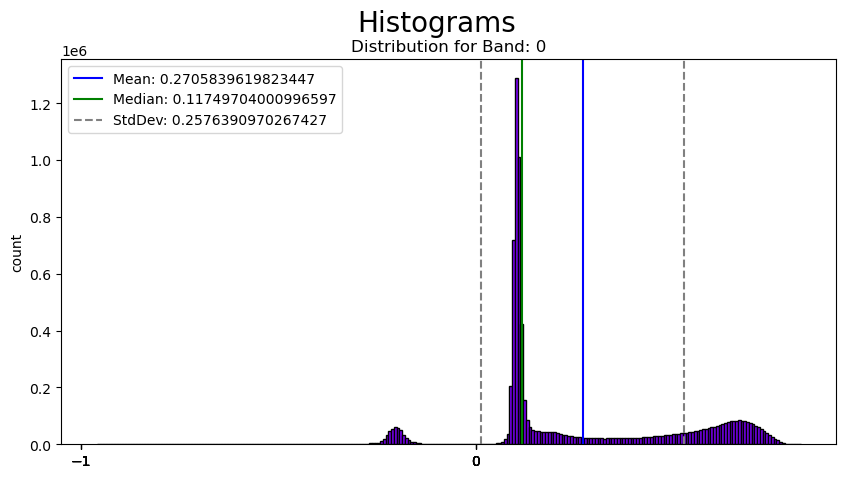

In [23]:
# Print a title.
print("NDVI Band Histogram")

# Plot the histogram for the NDVI image.
fayoum_ndvi.plot_histograms(geometry=fayoum_aoi,
                             plot_properties={"figsize":(10,5)})

The histogram shows how many pixels there are in the image for every possible NDVI value (between -1 to 1). On this graph, you can see three main spikes. Based on what you saw earlier of the NDVI values per land-cover types: 
* The first spike, below 0, must correspond to the water pixels, 
* The second very high one, slightly above 0, must correspond to the desert pixels, 
* The third one, more spread out and closer to 1, must correspond to the vegetation pixels. 

The spikes form because all the pixels representing a specific land-cover type have similar NDVI values. The spike representing water is modest in height, because only a small number of the pixels in the image represent water. The desert spike is particularly tall, because there are a large number of desert pixels in the image, all with very similar NDVI values. The area of the histogram representing vegetation values is more of a hump than a spike because different types of vegetation have slightly different NDVI values that are all at the positive end of the range from 0 to 1.

The built-up (towns and villages) pixels have NDVI values higher than desert pixels and lower than vegetation pixels. They also do not form a clear spike but must be to the right of the desert spike and to the left of the vegetation hump.

Next, you'll generate the histogram for the NDWI raster.  

29. Run the cell below to show the histogram of the NDWI raster.

NDWI Band Histogram


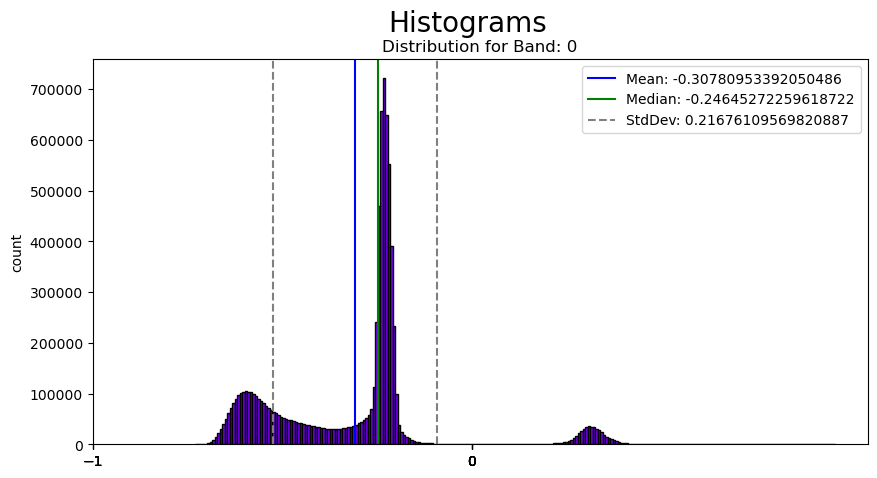

In [24]:
# Print a title.
print("NDWI Band Histogram")

# Plot the histogram for the NDWI image.
fayoum_ndwi.plot_histograms(geometry=fayoum_aoi,
                             plot_properties={"figsize":(10,5)})

The NDWI histogram looks strikingly like a mirror image of the NDVI one. The pixels that have high NDWI values tend to have low NDVI values, and vice versa. 

Can you locate the vegetation, desert, and water spikes in this histogram?

It can be particularly useful to use these histograms to choose threshold values for binary rasters of the type you generated earlier in the workflow. As you identify an area of the histogram that corresponds to a specific land-cover type, you can find the  range of index values on the x-axis that define the edges of the associated spike or hump. These values can then be used as thresholds to extract the corresponding land-cover pixels.

**Note:** The histograms also show summary statistics such as **Mean**, **Median**, and **StdDev** (Standard deviation). If needed, you can compute and access these summary values in your code using the [compute_stats_and_histograms](https://developers.arcgis.com/python/api-reference/arcgis.raster.toc.html#arcgis.raster.ImageryLayer.compute_stats_and_histograms) function.

## Stretch goal - Extract the desert pixels <a class="anchor" id="stretch"></a>

As a stretch goal, try to extract the desert pixels from the NDVI raster. Then display the resulting desert_pixels raster on a map.

**Hint:** 
You will need to use lower and upper thresholds, with a syntax such as this one:

`fayoum_ndvi > 0 and fayoum_ndvi <= 0.12`

Also, you should not include the built-up pixels in your desert_pixels raster, even though they are relatively close in value.



## Summary <a class="anchor" id="summary"></a>

In this notebook, you used the ArcGIS API for Python to identify water and vegetation in the El Fayoum oasis in Egypt. You selected a recent satellite image and applied the NDVI and NDWI spectral indices to it. You then extracted the water and vegetation pixels by applying thresholding and masking. You also learned to apply a stretch to a raster to symbolize it with a specific color, and generate histograms for spectral index rasters.

You can find other notebooks like this one in the [Analyze imagery with ArcGIS Notebooks](https://learn.arcgis.com/en/paths/analyze-imagery-with-arcgis-notebooks/) learning path. For more information about remote sensing in ArcGIS, see also the [Introduction to Imagery and Remote Sensing](https://introduction-to-remote-sensing-learngis.hub.arcgis.com/) curriculum.

## Acknowledgments <a class="anchor" id="acknowledgments"></a>

Author: Delphine Khanna, principal product engineer at Esri.

Thank you to professor Karen Schuckman, Pennsylvania State University, for her invaluable help. 

Introduction's photo: © 2025 Adobe Stock. All rights reserved.

If you experience any issues with this notebook, please contact <LearnArcGISSupport@esri.com>.